test

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
surcharge_amount = 0.5
# Load a CSV file named 'data.csv' into a DataFrame
items = pd.read_csv('items.csv')
sales = pd.read_csv('sales.csv')

items.head()


,item_name,price,production_cost,item_type,drink_temperature,drink_type
0,Espresso,3.00,0.80,Drink,Hot,Coffee
1,Americano,3.50,1.00,Drink,Hot,Coffee
2,Latte,4.50,1.20,Drink,Hot,Coffee
3,Cappuccino,4.25,1.15,Drink,Hot,Coffee
4,Flat White,4.75,1.25,Drink,Hot,Coffee


In [10]:
sales.head()

,date,time,item_name,transaction_type,own_cup,surcharge,customer_id
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589


In [12]:
with_prices = pd.merge(sales, items, on='item_name', how='inner')
with_prices.head()

,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee


In [ ]:
with_prices["datetime"] = pd.to_datetime(with_prices["date"] + " " + with_prices["time"])



,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type,datetime
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee,2022-01-01 07:03:30
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee,2022-01-01 07:30:58
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee,2022-01-01 08:32:23
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee,2022-01-01 08:45:03
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee,2022-01-01 09:03:47


In [57]:
with_prices["surcharge_amount"] =  with_prices["surcharge"] * surcharge_amount

with_prices["surcharge_amount"].sum()

1726.0

<Axes: xlabel='datetime'>

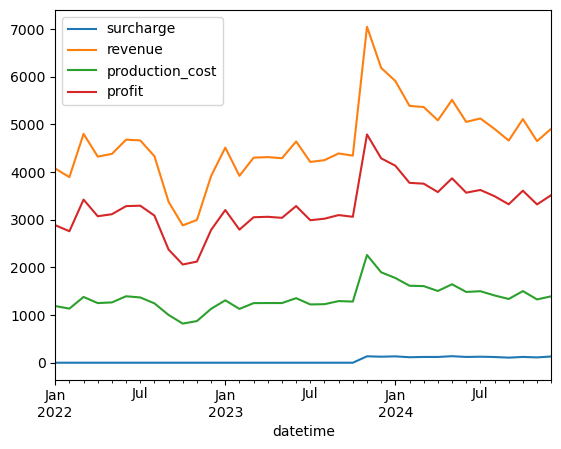

In [58]:


# start_date = pd.to_datetime(with_prices["date"][0])
# end_date = pd.to_datetime(with_prices["date"][len(with_prices) -1])

# period = pd.Timedelta(days=30)

# dates = pd.date_range(start=start_date, periods=300, freq=period) # Hourly data
# df = pd.DataFrame(with_prices, index=dates)

# # Resample to daily sums
# daily_sums = df['price'].resample('D').sum()
monthly_items = with_prices.groupby(pd.PeriodIndex(with_prices['datetime'], freq="M"))

monthly_averaged_items = pd.DataFrame()

monthly_averaged_items["surcharge"] = monthly_items["surcharge_amount"].sum()

monthly_averaged_items["revenue"] = monthly_items['price'].sum() + monthly_averaged_items["surcharge"]

monthly_averaged_items["production_cost"] = monthly_items['production_cost'].sum()

monthly_averaged_items["profit"] = monthly_averaged_items["revenue"] - monthly_averaged_items["production_cost"]

times = monthly_averaged_items.index.to_timestamp()

monthly_averaged_items.plot()

# # Create the plot
# plt.figure(figsize=(10, 6))


# plt.title('Daily Sums Over Time')
# plt.xlabel('Date')
# plt.ylabel('Daily Sum')
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [43]:
False * 8

0